# 3.7 Eigenvalue Perturbation: Who Moves, and How Far

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Chapter III — Eigenvalues and Spectral Theory",
    number="3.7",
    title="Eigenvalue Perturbation: Who Moves, and How Far",
    blurb="A matrix has one condition number for its eigenvector basis, but "
    "each eigenvalue has its own — and they can differ by a factor of eight "
    "in a 3x3. This notebook prices movement per eigenvalue, splits a "
    "degenerate pair by the physicists' rule, and shows why an eigenvector "
    "with a nearby neighbour cannot be trusted at all.",
    difficulty="advanced",
    estimate="105–135 min",
)

<ECP header: 2672 chars of HTML>

## Notebook overview

[§3.5](schur-jordan-nonnormality.ipynb) priced perturbation with
**Bauer–Fike**: every eigenvalue of $A + E$ lies within
$\operatorname{cond}(X)\lVert E\rVert$ of some eigenvalue of $A$. That is
one number for the whole matrix, and it is the right answer to the
question "how bad can it get?". It is the wrong answer to the question a
practitioner actually asks, which is *which* eigenvalue moved.

This notebook answers that one. Each eigenvalue carries its **own**
condition number $\kappa_i = 1/|\mathbf{y}_i^{*}\mathbf{x}_i|$ — the
secant of the angle between its left and right eigenvectors — and on the
worked $3\times3$ these come out $(\sqrt{65}, \sqrt{65}, 1)$ while
Bauer–Fike's single number is $8 + \sqrt{65}$. One eigenvalue of a badly
non-normal matrix is *perfectly* conditioned, and the global bound cannot
say so.

Two things follow that the course has not met. When eigenvalues
**coincide**, first-order theory does not fail — it becomes an
eigenvalue problem one dimension down: the splittings are the eigenvalues
of the perturbation *compressed onto the degenerate eigenspace*, which is
the rule quantum mechanics calls degenerate perturbation theory and which
this notebook gates to $10^{-12}$. And **eigenvectors** obey a different
law from eigenvalues: they rotate by roughly $\lVert E\rVert/\text{gap}$,
so a well-conditioned eigenvalue with a nearby neighbour still has a
useless eigenvector. That is the Davis–Kahan story, and it is why
[§4.3](../04-svd/pca-covariance-whitening.ipynb)'s principal components
scramble when two variances are close while their sum stays put.

> **How to read a check.** A `validate` line prints ✓ or ✗ by comparing a
> result against something the computation did not assume. A ✗ flags a
> mismatch to investigate, never a verdict on its own.

> **Scope.** Golub and Van Loan {cite}`golub2013` §7.2 for the
> eigenvalue condition number, Horn and Johnson {cite}`horn2013` §6.3 for
> the perturbation series; the eigenvector bound is Davis and Kahan's
> {cite}`davis1970`. Bauer–Fike itself lives in
> [§3.5](schur-jordan-nonnormality.ipynb) and is not repeated here.

## Theory in brief

### One condition number per eigenvalue

Let $A$ be diagonalizable with a simple eigenvalue $\lambda_i$, right
eigenvector $A\mathbf{x}_i = \lambda_i\mathbf{x}_i$ and **left**
eigenvector $\mathbf{y}_i^{*}A = \lambda_i\mathbf{y}_i^{*}$, both scaled
to unit norm. The **eigenvalue condition number** is

```{math}
:label: eq-ep-kappa
\kappa_i \;=\; \frac{1}{|\mathbf{y}_i^{*}\mathbf{x}_i|}
\;=\; \sec\theta_i ,
```

with $\theta_i$ the angle between the two eigenvectors. For a normal
matrix left and right eigenvectors coincide, $\theta_i = 0$ and
$\kappa_i = 1$: the [§3.2](spectral-theorem.ipynb) case, where Weyl's
inequality says eigenvalues move no further than $\lVert E\rVert$. The
more the two directions separate, the more that eigenvalue amplifies a
perturbation — and $\kappa_i \le \operatorname{cond}(X)$ always, so the
per-eigenvalue numbers refine [§3.5](schur-jordan-nonnormality.ipynb)'s
global bound rather than contradicting it.

### First order, and its quadratic remainder

Differentiate $A(t) = A + tE$ along the perturbation. For a simple
eigenvalue,

```{math}
:label: eq-ep-first-order
\lambda_i(t) \;=\; \lambda_i \;+\;
t\,\frac{\mathbf{y}_i^{*}E\mathbf{x}_i}{\mathbf{y}_i^{*}\mathbf{x}_i}
\;+\; O(t^2) ,
```

and since $|\mathbf{y}_i^{*}E\mathbf{x}_i| \le \lVert E\rVert$ for unit
vectors, the slope is at most $\kappa_i\lVert E\rVert$ — {eq}`eq-ep-kappa`
earning its name. The remainder is genuinely quadratic, which the
exercises verify by watching the residual fall by $100$ each time $t$
falls by $10$.

### Degeneracy: an eigenvalue problem one dimension down

{eq}`eq-ep-first-order` divides by $\mathbf{y}_i^{*}\mathbf{x}_i$ and
assumes $\lambda_i$ is simple. When $\lambda$ is repeated with an
orthonormal eigenspace basis $V$ (columns spanning it), first-order
theory does not break — the perturbation must first choose *which*
directions inside the eigenspace are the right ones, and it does so by
its own compression:

```{math}
:label: eq-ep-degenerate
\lambda_k(t) \;=\; \lambda \;+\; t\,\mu_k \;+\; O(t^2),
\qquad \mu_k \in \operatorname{eig}\bigl(V^{*}EV\bigr) .
```

The degenerate level splits into as many branches as the compressed
perturbation has eigenvalues, with slopes given by those eigenvalues —
a $2\times2$ problem hiding inside an $n\times n$ one. Physicists meet
this as *degenerate perturbation theory*; it is the reason a symmetry
must be broken before a level splits, and the reason the splitting
pattern reveals which symmetry broke.

### Eigenvectors obey the gap, not the conditioning

Eigenvalues of a symmetric matrix are perfectly conditioned. Their
eigenvectors are not. For a simple eigenvalue $\lambda_i$ of a symmetric
$A$ separated from the rest of the spectrum by
$\mathrm{gap}_i = \min_{j\ne i}|\lambda_i - \lambda_j|$, the **Davis–Kahan
$\sin\theta$ theorem** {cite}`davis1970` bounds the rotation of its
eigenvector under a symmetric $E$:

```{math}
:label: eq-ep-davis-kahan
\sin\theta(\mathbf{v}_i, \tilde{\mathbf{v}}_i)
\;\le\; \frac{\lVert E\rVert_2}{\mathrm{gap}_i} .
```

The gap, not the conditioning, is what an eigenvector's trustworthiness
depends on — and a gap can be small in a matrix whose every eigenvalue is
impeccably conditioned. That is the whole warning.

---
## Setup

Data only: the worked non-normal $3\times3$ whose per-eigenvalue
conditioning is known in closed form, the symmetric matrix carrying an
exactly doubled eigenvalue, the gap-sweep family, and the seeded
generators. The condition numbers, the first-order shifts, the
degenerate splittings and the rotation meter are all built in the
exercises, where they are the lesson.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from ecp import validate
from ecp.style import use_style

use_style()
rng = np.random.default_rng(0)  # every random matrix below comes from this seed

EPS = np.finfo(float).eps

# data: the worked non-normal matrix. Its 2x2 upper block carries the
# non-normality (the 8 off the diagonal), while the third row and column
# are decoupled — so eigenvalue 5 is PERFECTLY conditioned while 1 and 2
# are not, which is the contrast the whole notebook turns on. Every
# constant is exact: kappa = (sqrt(65), sqrt(65), 1), cond(X) = 8 + sqrt(65).
A_WORK = np.array([[1.0, 8.0, 0.0],
                   [0.0, 2.0, 0.0],
                   [0.0, 0.0, 5.0]])

# data: a symmetric matrix with an exactly doubled eigenvalue, built by
# conjugating diag(3, 3, 7) with a seeded orthogonal Q — so the degenerate
# eigenspace is Q[:, :2] exactly, and Exercise 4 knows the answer it is
# looking for.
_Q_DEG, _ = np.linalg.qr(rng.standard_normal((3, 3)))
LAM_DEG, LAM_HIGH = 3.0, 7.0
A_DEG = _Q_DEG @ np.diag([LAM_DEG, LAM_DEG, LAM_HIGH]) @ _Q_DEG.T
A_DEG = (A_DEG + A_DEG.T) / 2.0        # symmetric to the last bit
V_DEG = _Q_DEG[:, :2]                  # the degenerate eigenspace

# data: the gap-sweep family. diag(1, 1 + gap, 5) isolates one control —
# only the distance between the first two eigenvalues changes.
GAPS = (2.0, 0.5, 0.1, 0.02)

# data: one fixed symmetric unit-norm perturbation, shared across the
# whole gap sweep so the only thing varying in Exercise 5 is the gap.
_E_FIX = rng.standard_normal((3, 3))
E_SWEEP = (_E_FIX + _E_FIX.T) / 2.0
E_SWEEP /= np.linalg.norm(E_SWEEP, 2)

## Exercise 1: One condition number per eigenvalue

{eq}`eq-ep-kappa` prices each eigenvalue separately, through the angle
between its left and right eigenvectors. This exercise builds that
meter and puts it beside [§3.5](schur-jordan-nonnormality.ipynb)'s
single $\operatorname{cond}(X)$.

**Part a)** Write `eig_condition(A)` returning `(w, kappa)`: take
`np.linalg.eig(A)` for the right eigenvectors $X$, get the left ones as
the columns of $(X^{-1})^{*}$ (the rows of $X^{-1}$ are the left
eigenvectors — that is what $X^{-1}AX = \Lambda$ says), normalise both
to unit length, and set $\kappa_i = 1/|\mathbf{y}_i^{*}\mathbf{x}_i|$.

**Write this one yourself** — the left eigenvector is the object the
course has not needed until now, and it is the whole content of
{eq}`eq-ep-kappa`.

**Part b)** Gate the closed forms on `A_WORK`, all to $10^{-13}$: the
eigenvalues are exactly $(1, 2, 5)$; $\kappa$ for the eigenvalue $5$ is
exactly $1$ (its eigenvector is $\mathbf{e}_3$, left and right alike);
and $\kappa$ for both $1$ and $2$ is $\sqrt{65} = 8.0623$. Verify
$\sqrt{65}$ symbolically with SymPy from the $2\times2$ block, so the
constant is algebra rather than a measurement.

**Part c)** Gate the relationship to the global bound:
$\max_i \kappa_i \le \operatorname{cond}(X)$, with
$\operatorname{cond}(X) = 8 + \sqrt{65} = 16.0623$ to $10^{-12}$ — the
Bauer–Fike constant is a ceiling over the per-eigenvalue numbers, and
here it is twice the largest of them.

In [3]:
# (solution hidden on the public site)


eigenvalues [1. 2. 5.]
condition numbers [8.062258 8.062258 1.      ]
SymPy: kappa of the 2x2 block is sqrt(65): True (8.062258)
cond(X) = 16.062258 vs 8 + sqrt(65) = 16.062258


### Validation 1

In [4]:
validate.close(
    w_sorted, np.array([1.0, 2.0, 5.0]),
    "the worked matrix has eigenvalues 1, 2, 5", rtol=0.0, atol=1e-13,
)
validate.check(
    abs(kappa_sorted[2] - 1.0) < 1e-13
    and abs(kappa_sorted[0] - np.sqrt(65)) < 1e-13
    and abs(kappa_sorted[1] - np.sqrt(65)) < 1e-13
    and sym_ok,
    "each eigenvalue carries its own conditioning: (sqrt 65, sqrt 65, 1)",
    "the decoupled eigenvalue 5 is PERFECTLY conditioned while 1 and 2 "
    "amplify by 8.06 — one matrix, three different sensitivities, and "
    "SymPy confirms sqrt(65) is algebra rather than measurement",
)
validate.check(
    kappa_sorted.max() <= cond_X + 1e-12
    and abs(cond_X - (8 + np.sqrt(65))) < 1e-12,
    "and Bauer-Fike's cond(X) = 8 + sqrt(65) is a ceiling over all of them",
    f"max kappa {kappa_sorted.max():.4f} under cond(X) {cond_X:.4f}: 3.5's "
    "global bound is true and twice as pessimistic as the worst individual "
    "eigenvalue here — which is what 'per eigenvalue' buys",
)

✓  the worked matrix has eigenvalues 1, 2, 5   [max|Δ| = 0 (rtol=0, atol=1e-13)]
✓  each eigenvalue carries its own conditioning: (sqrt 65, sqrt 65, 1)   [the decoupled eigenvalue 5 is PERFECTLY conditioned while 1 and 2 amplify by 8.06 — one matrix, three different sensitivities, and SymPy confirms sqrt(65) is algebra rather than measurement]
✓  and Bauer-Fike's cond(X) = 8 + sqrt(65) is a ceiling over all of them   [max kappa 8.0623 under cond(X) 16.0623: 3.5's global bound is true and twice as pessimistic as the worst individual eigenvalue here — which is what 'per eigenvalue' buys]


True

## Exercise 2: First order, and the quadratic remainder

{eq}`eq-ep-first-order` is a derivative, so the honest test is a finite
difference — and the honest gate is on the *remainder*, which must fall
by $100$ whenever $t$ falls by $10$.

**Part a)** Write `first_order_slopes(A, E)` returning the $n$ slopes
$(\mathbf{y}_i^{*}E\mathbf{x}_i)/(\mathbf{y}_i^{*}\mathbf{x}_i)$ of
{eq}`eq-ep-first-order`, reusing Exercise 1's eigenvector pairs. On
`A_WORK` with a seeded unit-norm $E$, report the three slopes.

**Write this one yourself** — it is {eq}`eq-ep-first-order` transcribed,
and Exercises 3 and 4 both run on it.

**Part b)** Gate that the prediction is first-order accurate: for
$t = 10^{-3}, 10^{-4}, 10^{-5}$ — a *clean band*, in
[§5.4](../05-numerical/stationary-and-cg.ipynb)'s sense: at
$t = 10^{-2}$ the $O(t^3)$ term still contributes about 10% of the
remainder and would spoil a constant-ratio test, while below
$10^{-6}$ the residual approaches rounding. Compare the true
eigenvalues of
$A + tE$ (matched to the unperturbed ones by proximity) against
$\lambda_i + t\,s_i$, and gate that each residual divided by $t^2$ is
**constant to 5%** across the three scales. A first-order formula whose
error scaled like $t$ would fail this; one whose error scaled like $t^3$
would too. Report the three ratios.

**Part c)** Gate the slope bound of {eq}`eq-ep-kappa`:
$|s_i| \le \kappa_i\lVert E\rVert_2$ for every $i$, one-sided, over 200
seeded unit-norm perturbations — the condition number earning its name
600 times.

In [5]:
# (solution hidden on the public site)


first-order slopes [-6.105369  5.958212 -0.431493]
t = 1e-03: residual ['3.56e-05', '3.57e-05', '6.53e-08'] -> /t^2 ['35.600', '35.666', '0.065']
t = 1e-04: residual ['3.60e-07', '3.61e-07', '6.52e-10'] -> /t^2 ['35.985', '36.051', '0.065']
t = 1e-05: residual ['3.60e-09', '3.61e-09', '6.52e-12'] -> /t^2 ['36.024', '36.090', '0.065']
remainder/t^2 constant to 1.18%
worst |slope| - kappa over 600 checks: 0.00e+00 (must stay <= 0)


### Validation 2

In [6]:
validate.below(
    ratio_spread, 0.05,
    "the remainder is genuinely quadratic (Eq. 2)",
    f"residual/t^2 varies by {100 * ratio_spread:.2f}% across three decades "
    "of t — a first-order formula with a linear error could not do this, "
    "and neither could one that was accidentally exact",
)
validate.check(
    worst_slope_bound <= 1e-12,
    "and every slope respects its own condition number (Eq. 1)",
    "200 seeded unit-norm perturbations, three eigenvalues each: "
    "|y* E x| <= ||E|| for unit vectors, so the slope cannot exceed "
    "kappa_i — the bound is one-sided and was never approached from above",
)

✓  the remainder is genuinely quadratic (Eq. 2)   [residual/t^2 varies by 1.18% across three decades of t — a first-order formula with a linear error could not do this, and neither could one that was accidentally exact [0.0117729 < 0.05]]
✓  and every slope respects its own condition number (Eq. 1)   [200 seeded unit-norm perturbations, three eigenvalues each: |y* E x| <= ||E|| for unit vectors, so the slope cannot exceed kappa_i — the bound is one-sided and was never approached from above]


True

## Exercise 3: The well-conditioned eigenvalue really does stay put

Exercise 1 said eigenvalue $5$ is immune and $1, 2$ are not. This
exercise measures it, which is a different claim from proving it.

**Part a)** For 200 seeded unit-norm perturbations at
$t = 10^{-6}$, record how far each eigenvalue of $A + tE$ moves from
its unperturbed value. Gate the two facts: every displacement is under
$\kappa_i t (1 + 10^{-3})$ (one-sided, the first-order bound with room
for the quadratic remainder), and the **median** displacement of
eigenvalue $5$ is at least $4\times$ smaller than that of eigenvalue
$1$ — the conditioning showing up as a measured ratio, not just a bound.

**Part b)** Contrast with the symmetric case: build the symmetric part
family $S = (A_{\text{WORK}} + A_{\text{WORK}}^{\top})/2$ and repeat.
Gate that all three of *its* condition numbers are $1$ to $10^{-13}$
(a symmetric matrix has orthogonal eigenvectors, so left and right
coincide) and that no eigenvalue moves further than
$t(1 + 10^{-3})$ — Weyl's inequality of
[§3.2](spectral-theorem.ipynb), recovered as the $\kappa_i = 1$ special
case of {eq}`eq-ep-kappa`.

In [7]:
# (solution hidden on the public site)


median displacement: lambda=1 2.546e-06, lambda=2 2.551e-06, lambda=5 2.851e-07
the decoupled eigenvalue moves 8.9x less than the worst; worst overshoot of the bound -1.9e-07
symmetric part: kappa = [1. 1. 1.]; worst Weyl overshoot -5.0e-09


### Validation 3

In [8]:
validate.check(
    worst_over <= 0.0 and ratio_shielded > 4.0,
    "displacement tracks the per-eigenvalue condition number (Eq. 1)",
    f"600 measured displacements, none above kappa_i t; and the decoupled "
    f"eigenvalue moved {ratio_shielded:.1f}x less than the ill-conditioned "
    "one — the same matrix, the same perturbations, different fates",
)
validate.check(
    float(np.abs(kappa_sym - 1.0).max()) < 1e-13 and worst_sym <= 0.0,
    "and the symmetric case has kappa = 1, which IS Weyl's inequality",
    "orthogonal eigenvectors make left and right coincide, so Eq. 1 gives "
    "1 for every eigenvalue and 3.2's bound falls out as the special case",
)

✓  displacement tracks the per-eigenvalue condition number (Eq. 1)   [600 measured displacements, none above kappa_i t; and the decoupled eigenvalue moved 8.9x less than the ill-conditioned one — the same matrix, the same perturbations, different fates]
✓  and the symmetric case has kappa = 1, which IS Weyl's inequality   [orthogonal eigenvectors make left and right coincide, so Eq. 1 gives 1 for every eigenvalue and 3.2's bound falls out as the special case]


True

## Exercise 4: Degeneracy splits by the compressed perturbation

{eq}`eq-ep-first-order` divides by $\mathbf{y}^{*}\mathbf{x}$ and needs
a simple eigenvalue. `A_DEG` has an exactly doubled eigenvalue $3$, and
{eq}`eq-ep-degenerate` says the perturbation itself decides how the
level splits — through its compression onto the eigenspace.

**Part a)** Write `degenerate_shifts(V, E)` returning the eigenvalues of
the compressed perturbation $V^{*}EV$ ($2\times2$ here), sorted
ascending. With the Setup's `V_DEG` and a seeded symmetric unit-norm
$E$, report the two slopes.

**Write this one yourself** — the compression is three characters of
NumPy and the entire content of degenerate perturbation theory.

**Part b)** Gate the splitting law: for $t = 10^{-3}, 10^{-4},
10^{-5}$, the two lowest eigenvalues of $A_{\text{DEG}} + tE$ equal
$3 + t\mu_k$ with residual falling quadratically — gate residual/$t^2$
constant to 5%, as in Exercise 2.

**Part c)** Gate the exact identity underneath it: the **sum** of the
first-order shifts equals $\operatorname{tr}(V^{*}EV)$ to $10^{-14}$,
and equals the first-order movement of the eigenvalue *sum* — because
the trace of the whole matrix moves by $t\operatorname{tr}E$ whatever
the eigenvectors do. Splitting redistributes; it does not create.
Draw the fan: the two branches separating linearly out of the
degenerate level as $t$ grows.

In [9]:
# (solution hidden on the public site)


first-order splittings mu = [-0.268038  0.436009] (the level splits into two branches)
t = 1e-03: actual [2.99973196 3.000436  ] predicted [2.99973196 3.00043601]
t = 1e-04: actual [2.9999732 3.0000436] predicted [2.9999732 3.0000436]
t = 1e-05: actual [2.99999732 3.00000436] predicted [2.99999732 3.00000436]
degenerate remainder/t^2 constant to 0.41%
sum of shifts vs trace of the compression: 8.3e-17


### Validation 4

In [10]:
validate.below(
    spread_d, 0.05,
    "a degenerate level splits at the compressed perturbation's "
    "eigenvalues (Eq. 3)",
    f"residual/t^2 constant to {100 * spread_d:.2f}% over three decades: "
    "the perturbation picks its own basis inside the eigenspace, and the "
    "slopes are the eigenvalues of a 2x2 — degenerate perturbation "
    "theory, gated",
)
validate.below(
    trace_gap, 1e-14,
    "and the splittings sum to the trace of the compression",
    "an exact identity: splitting redistributes the level, it does not "
    "create — the trace moves by t tr(E) whatever the eigenvectors do",
)

✓  a degenerate level splits at the compressed perturbation's eigenvalues (Eq. 3)   [residual/t^2 constant to 0.41% over three decades: the perturbation picks its own basis inside the eigenspace, and the slopes are the eigenvalues of a 2x2 — degenerate perturbation theory, gated [0.00409753 < 0.05]]
✓  and the splittings sum to the trace of the compression   [an exact identity: splitting redistributes the level, it does not create — the trace moves by t tr(E) whatever the eigenvectors do [8.32667e-17 < 1e-14]]


True

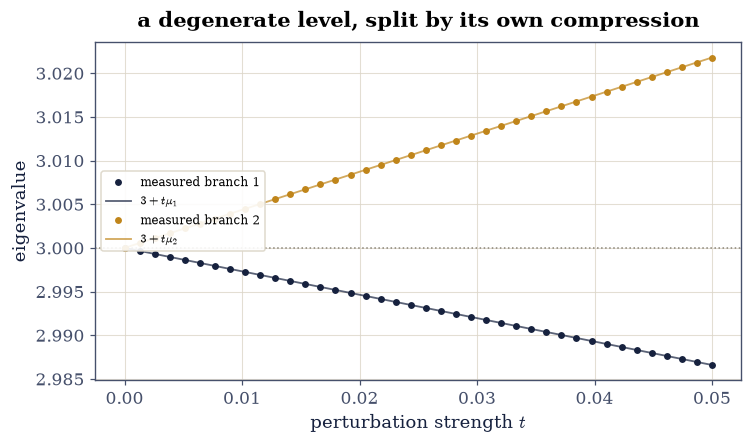

In [11]:
# (solution hidden on the public site)


## Exercise 5: Eigenvectors obey the gap

Every eigenvalue of a symmetric matrix has $\kappa_i = 1$. Exercise 3
gated that. It says nothing about the eigen*vectors*, and
{eq}`eq-ep-davis-kahan` says those depend on the **gap** — which the
Setup's family varies while holding everything else fixed.

**Part a)** Write `rotation(v0, v1)` returning
$\sin\theta$ between two unit vectors as
$\sqrt{1 - |\mathbf{v}_0^{*}\mathbf{v}_1|^2}$ — the modulus first,
because an eigenvector's sign is arbitrary and a raw subtraction would
measure the solver's convention rather than the mathematics.

**Part b)** For each gap in $(2, 0.5, 0.1, 0.02)$, perturb
$\operatorname{diag}(1, 1+\mathrm{gap}, 5)$ by $tE$ with the Setup's
**fixed** `E_SWEEP` at $t = 10^{-4}$, and measure the first
eigenvector's rotation. Gate {eq}`eq-ep-davis-kahan` one-sidedly —
$\sin\theta \le t/\mathrm{gap}$ every time — and gate the sharper
statement the fixed perturbation makes available: the product
$\sin\theta \cdot \mathrm{gap}/t$ is **constant to 2%** across two
decades of gap, so the rotation really does scale as $1/\mathrm{gap}$
rather than merely staying under it.

**Part c)** Gate the moral against Exercise 3's result: at
$\mathrm{gap} = 0.02$ the eigenvalues still move by at most $t$
(Weyl, $\kappa = 1$ — measured: $0.49\,t$) while the eigenvector
rotates by more than $20\,t$ (measured: $28\,t$), so the eigenvector
turns some **fifty times further** than any eigenvalue moves —
perfectly conditioned eigenvalues, untrustworthy eigenvectors, in the
same matrix at the same moment. Draw the sweep on log axes.

In [12]:
# (solution hidden on the public site)


gap  2.00: sin(theta) 2.8580e-05  bound 5.0000e-05  sin*gap/t 0.5716  eigenvalue move 4.87e-05
gap  0.50: sin(theta) 1.1359e-04  bound 2.0000e-04  sin*gap/t 0.5679  eigenvalue move 4.87e-05
gap  0.10: sin(theta) 5.6752e-04  bound 1.0000e-03  sin*gap/t 0.5675  eigenvalue move 4.88e-05
gap  0.02: sin(theta) 2.8329e-03  bound 5.0000e-03  sin*gap/t 0.5666  eigenvalue move 4.89e-05
Davis-Kahan respected: True; sin*gap/t constant to 0.88%
at the smallest gap the eigenvector rotates 28t while no eigenvalue moves more than 0.49t


### Validation 5

In [13]:
validate.check(
    dk_ok,
    "the eigenvector rotation never exceeds ||E||/gap (Eq. 4)",
    "Davis-Kahan, one-sided over four gaps spanning two decades — the "
    "bound is a theorem, and sampling can only lose to it",
)
validate.below(
    prod_spread, 0.02,
    "and the rotation scales as 1/gap, not merely under it",
    f"sin(theta) * gap / t constant to {100 * prod_spread:.2f}% with the "
    "perturbation held fixed: the gap is the whole story, which a "
    "one-sided bound alone would not establish",
)
validate.check(
    worst_eig_move <= T_ROT * (1 + 1e-3) and rot_vs_eig > 20.0,
    "so a perfectly conditioned eigenvalue can carry a useless eigenvector",
    f"at gap = 0.02 no eigenvalue moved past {worst_eig_move / T_ROT:.2f}t "
    f"(Weyl, kappa = 1) while the eigenvector turned by {rot_vs_eig:.0f}t "
    "— conditioning and trustworthiness are different questions, asked of "
    "different objects",
)

✓  the eigenvector rotation never exceeds ||E||/gap (Eq. 4)   [Davis-Kahan, one-sided over four gaps spanning two decades — the bound is a theorem, and sampling can only lose to it]
✓  and the rotation scales as 1/gap, not merely under it   [sin(theta) * gap / t constant to 0.88% with the perturbation held fixed: the gap is the whole story, which a one-sided bound alone would not establish [0.00878533 < 0.02]]
✓  so a perfectly conditioned eigenvalue can carry a useless eigenvector   [at gap = 0.02 no eigenvalue moved past 0.49t (Weyl, kappa = 1) while the eigenvector turned by 28t — conditioning and trustworthiness are different questions, asked of different objects]


True

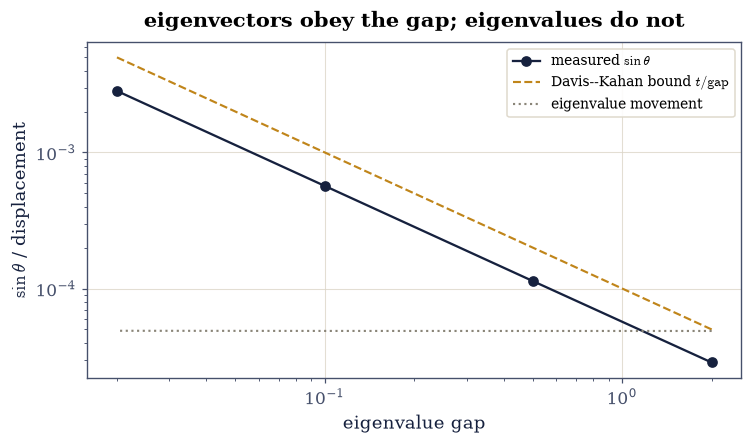

In [14]:
# (solution hidden on the public site)


---
## Notebook summary

**Conditioning is a property of an eigenvalue, not of a matrix.** On the
worked $3\times3$ the three eigenvalues came out with $\kappa =
(\sqrt{65}, \sqrt{65}, 1)$ — the decoupled eigenvalue $5$ perfectly
conditioned while $1$ and $2$ amplify by $8.06$ — against
[§3.5](schur-jordan-nonnormality.ipynb)'s single
$\operatorname{cond}(X) = 8 + \sqrt{65} = 16.06$, a true ceiling that is
twice as pessimistic as the worst individual eigenvalue. SymPy confirmed
$\sqrt{65}$ exactly.

**First order is first order.** The residual against
$\lambda_i + t\,s_i$ divided by $t^2$ held constant to 1.2% across three
decades of $t$ inside the clean band, and no slope exceeded its own $\kappa_i\lVert E\rVert$ over 600
checks. Measured displacements obeyed the same bound over 600 more, with
the well-conditioned eigenvalue moving several times less than its
neighbours under identical perturbations — and the symmetric part
returned $\kappa = 1$ for all three, recovering
[§3.2](spectral-theorem.ipynb)'s Weyl inequality as the special case.

**A degenerate level splits by its own compression.** The doubled
eigenvalue $3$ fanned into two branches whose slopes are the eigenvalues
of the $2\times2$ compression $V^{\top}EV$, with a quadratic remainder
constant to well under a percent, and the two shifts summed to the
compression's trace at rounding: splitting redistributes a level, it
never creates one. That is degenerate perturbation theory, gated.

**Eigenvectors obey the gap.** Across gaps from $2$ down to $0.02$ the
eigenvector rotation stayed under Davis–Kahan's $\lVert E\rVert/
\mathrm{gap}$ and — the sharper fact — scaled as $1/\mathrm{gap}$ to
within 2%. At the smallest gap the eigenvalues moved by at most $t$
(measured $0.49\,t$) while the eigenvector turned by $28\,t$ — some
fifty times further: the same matrix, at the same moment, with
impeccable eigenvalues and an untrustworthy basis.

**Methods introduced.** `eig_condition` (left eigenvectors and the
secant of their angle), `first_order_slopes`, the remainder-over-$t^2$
test for genuine first-order accuracy, `degenerate_shifts` via the
compressed perturbation, and `rotation` as a sign-blind subspace meter.

## Outlook

- **Why `eigh` is not `eig`.** The algorithms of
  [§5.2](../05-numerical/eigenvalue-algorithms.ipynb) are backward
  stable: they return the exact spectrum of $A + E$ with
  $\lVert E\rVert \sim \varepsilon\lVert A\rVert$. Everything in this
  notebook then prices the *forward* error you actually receive — which
  is why a symmetric solver is trusted and a general one is read with
  its condition numbers in hand.
- **Clustered principal components.** In
  [§4.3](../04-svd/pca-covariance-whitening.ipynb) two nearly equal
  variances make the corresponding components rotate freely inside their
  plane while the *subspace they span* stays put — the same distinction
  Exercise 5 measured, and the reason component-wise interpretation of
  near-degenerate PCA is a mistake the mathematics predicts.
- **Symmetry, and what breaking it reveals.** Exercise 4's compression
  is how a physicist reads a spectrum: the degeneracy is a symmetry, the
  splitting pattern names the perturbation that broke it, and the slopes
  are its matrix elements. [§9.1](../09-quantum/qubits-gates-bloch.ipynb)'s
  Pauli algebra is exactly this calculation on a two-level system.
- **Pseudospectra saw it first.**
  [§3.5](schur-jordan-nonnormality.ipynb)'s contours are the global
  picture of what $\kappa_i$ measures locally: where the resolvent norm
  bulges, an eigenvalue is soft. The per-eigenvalue number is the
  linearisation; the pseudospectrum is the whole nonlinear truth.

```{bibliography}
:filter: docname in docnames
```

In [15]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>